In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# ======= SUBJECT DATASETS (27 SUBJECTS) ======= #

file_list = [
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_1.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_2.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_3.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_4.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_5.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_6.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_7.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_8.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_9.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_10.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_11.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_12.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_13.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_14.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_15.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_16.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_17.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_18.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_19.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_20.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_21.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_22.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_23.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_24.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_25.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_26.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_27.csv'
]

# ======= OUTPUT DIRECTORIES ======= #

base_dir = r"C:\Users\franc\Desktop\GitHub\03-Test_2_Data_Scarcity"

results_dir = os.path.join(base_dir, "results")
os.makedirs(results_dir, exist_ok=True)

best_resnet_dir = os.path.join(base_dir, "best_model_resnet")
os.makedirs(best_resnet_dir, exist_ok=True)



In [3]:
# ======= CONFIG ======= #

N_PARTS = 10
TEST_SIZE = 0.5
RANDOM_STATE = 42  # Reproducibility
#EPOCHS = 250
EPOCHS = 150
#BATCH_SIZE = 128
BATCH_SIZE = 64

VAL_SPLIT = 0.2

# ======= LOGGING UTILS ======= #

log_path = os.path.join(results_dir, "RESNET_data_scarcity_log.txt")

def print_and_save(text, file):
    print(text)
    file.write(text + "\n")



In [4]:
# ======== RESNET MODEL ======== #

def create_residual(input_layer, factors, dropout_pcg):
    out = Dense(factors, activation="relu")(input_layer)
    out = BatchNormalization()(out)
    out = Dropout(dropout_pcg)(out)

    out = Add()([out, input_layer])

    out = Dense(factors, activation="relu")(out)
    out = BatchNormalization()(out)
    out = Dropout(dropout_pcg)(out)
    return out


def create_model(input_dim, num_classes, factors=256, dropout_pcg=0.25):
    inp = Input(shape=(input_dim,))

    out = Dense(factors, activation="relu")(inp)
    out = BatchNormalization()(out)
    out = Dropout(dropout_pcg)(out)

    out1 = create_residual(out, factors, dropout_pcg)

    out = Concatenate()([out1, inp])
    out = Dense(num_classes, activation="softmax")(out)

    model = Model(inp, out)

    opt = tf.keras.optimizers.Adam(learning_rate=1e-3, epsilon=1e-14)
    # opt = tf.keras.optimizers.RMSprop(learning_rate=1e-3, epsilon=1e-14)

    model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model

In [5]:
# ======== OVERSAMPLING ======== #

def oversample_balance(X_scaled: np.ndarray, y: np.ndarray, random_state=42):
    df = pd.DataFrame(X_scaled)
    df["Event Id"] = y

    counts = df["Event Id"].value_counts()
    max_n = counts.max()

    balanced = []
    for cls, cnt in counts.items():
        df_cls = df[df["Event Id"] == cls]
        if cnt < max_n:
            df_cls = resample(df_cls, replace=True, n_samples=max_n, random_state=random_state)
        balanced.append(df_cls)

    df_bal = pd.concat(balanced).sample(frac=1, random_state=random_state).reset_index(drop=True)
    Xb = df_bal.drop("Event Id", axis=1).values
    yb = df_bal["Event Id"].values
    return Xb, yb


In [6]:
# ======== CALLBACKS ======== #

def make_callbacks(weights_path):
    ckpt = ModelCheckpoint(
        filepath=weights_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=0
    )
    rlr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )
    es = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=False,  # We will load best weights from checkpoint
        verbose=0
    )
    return [ckpt, rlr, es]


with open(log_path, "w", encoding="utf-8") as f:

    # ===========================
    # 1) LOAD + CONCAT FULL DATASET
    # ===========================
    # MODIFIED: split 80/20 PER SUBJECT, then concat all trains and all tests
    train_parts = []
    test_parts = []

    # Use first file to define feature columns consistently
    first_df = pd.read_csv(file_list[0])
    if "Event Id" not in first_df.columns:
        raise ValueError("Column 'Event Id' was not found in the CSV files.")
    feature_cols = [c for c in first_df.columns if c != "Event Id"]

    for fp in file_list:
        df = pd.read_csv(fp)

        if "Event Id" not in df.columns:
            raise ValueError("Column 'Event Id' was not found in the CSV files.")

        X_subj = df[feature_cols].astype(float)
        y_subj = df["Event Id"].values

        X_train_subj, X_test_subj, y_train_subj, y_test_subj = train_test_split(
            X_subj, y_subj,
            test_size=0.2,
            shuffle=True,
            stratify=y_subj,
            random_state=RANDOM_STATE
        )

        train_df = X_train_subj.copy()
        train_df["Event Id"] = y_train_subj

        test_df = X_test_subj.copy()
        test_df["Event Id"] = y_test_subj

        train_parts.append(train_df)
        test_parts.append(test_df)

    train_final = pd.concat(train_parts, ignore_index=True)
    test_final = pd.concat(test_parts, ignore_index=True)

    full_df = pd.concat([train_final, test_final], ignore_index=True)

    if "Event Id" not in full_df.columns:
        raise ValueError("Column 'Event Id' was not found in the CSV files.")

    X_train_df = train_final[feature_cols].astype(float)
    y_train = train_final["Event Id"].values

    X_test_df = test_final[feature_cols].astype(float)
    y_test = test_final["Event Id"].values

    # ===========================
    # 2) SINGLE 50/50 SPLIT (FIXED TEST SET)
    # ===========================
    # (kept comment for consistency with your original structure)
    # Now train_final/test_final are already defined by per-subject 80/20 splits

    print_and_save(f"Total dataset: {full_df.shape}", f)
    print_and_save(f"Train (80% each subject):   {train_final.shape}", f)
    print_and_save(f"Test  (20% each subject):   {test_final.shape}", f)

    # Global classes mapping (consistent across all k)
    classes_global = np.sort(np.unique(np.concatenate([y_train, y_test])))
    to_index = {c: i for i, c in enumerate(classes_global)}
    NUM_CLASSES = len(classes_global)
    print_and_save(f"Number of global classes: {NUM_CLASSES}", f)

    # Check whether each part can contain all classes
    min_per_class = pd.Series(y_train).value_counts().min()
    print_and_save(f"Min samples per class in TRAIN: {int(min_per_class)}", f)
    if min_per_class < N_PARTS:
        print_and_save(
            f"WARNING: some classes have < {N_PARTS} samples in the train -> "
            "it is not possible for every part to contain ALL classes.",
            f
        )
    print_and_save("", f)

    # ===========================
    # 3) SPLIT TRAIN INTO 10 DISJOINT STRATIFIED PARTS
    # ===========================
    skf = StratifiedKFold(n_splits=N_PARTS, shuffle=True, random_state=RANDOM_STATE)
    partition_list = []

    for fold_id, (_, part_idx) in enumerate(skf.split(X_train_df, y_train), start=1):
        part_X = X_train_df.iloc[part_idx].copy()
        part_y = y_train[part_idx]
        part_df = part_X.copy()
        part_df["Event Id"] = part_y
        partition_list.append(part_df)

    # Quick print: class distribution per part
    print_and_save("Class distribution per part (min/max count per class in each part):", f)
    for i, part in enumerate(partition_list, start=1):
        vc = part["Event Id"].value_counts()
        print_and_save(
            f"  P{i}: size={len(part)} | class_count min={int(vc.min())} max={int(vc.max())} | "
            f"n_class_present={vc.shape[0]}",
            f
        )
    print_and_save("", f)

    # ===========================
    # 4) INCREMENTAL LOOP: k=1..10
    # ===========================
    X_test_only = test_final[feature_cols].astype(float)
    y_test_only = test_final["Event Id"].values
    y_test_idx = np.array([to_index[c] for c in y_test_only])

    results = []

    for k in range(1, N_PARTS + 1):
        print_and_save(f"\n===== TRAIN with P1..P{k} =====", f)

        train_subset = pd.concat(partition_list[:k], ignore_index=True)
        X_train_sub = train_subset[feature_cols].astype(float)
        y_train_sub = train_subset["Event Id"].values

        # Scaler: fit ONLY on the current subset (consistent with the incremental experiment)
        scaler = MinMaxScaler().fit(X_train_sub)
        X_train_scaled = scaler.transform(X_train_sub)
        X_test_scaled = scaler.transform(X_test_only)

        # Oversampling on the training subset
        X_train_bal, y_train_bal = oversample_balance(X_train_scaled, y_train_sub, random_state=RANDOM_STATE)

        # Global one-hot encoding
        y_train_bal_idx = np.array([to_index[c] for c in y_train_bal])
        y_train_cat = to_categorical(y_train_bal_idx, num_classes=NUM_CLASSES)

        # Model
        model = create_model(input_dim=X_train_bal.shape[1], num_classes=NUM_CLASSES)

        # Save weights inside best_model_resnet
        weights_path = os.path.join(best_resnet_dir, f"best_weights_P1_P{k}.weights.h5")
        callbacks = make_callbacks(weights_path)

        # Fit
        history = model.fit(
            X_train_bal, y_train_cat,
            validation_split=VAL_SPLIT,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=0
        )

        # Load best weights
        model.load_weights(weights_path)

        # Test
        y_pred = model.predict(X_test_scaled, verbose=0)
        y_pred_idx = np.argmax(y_pred, axis=1)

        acc = accuracy_score(y_test_idx, y_pred_idx)
        prec = precision_score(y_test_idx, y_pred_idx, average="macro", zero_division=0)
        rec  = recall_score(y_test_idx, y_pred_idx, average="macro", zero_division=0)
        f1m  = f1_score(y_test_idx, y_pred_idx, average="macro")

        print_and_save(
            f"Test Acc: {acc:.4f} | "
            f"Macro-Prec: {prec:.4f} | "
            f"Macro-Rec: {rec:.4f} | "
            f"Macro-F1: {f1m:.4f}",
            f
        )
        
        results.append({
            "k_parts": k,
            "train_rows_raw": len(train_subset),
            "train_rows_bal": len(X_train_bal),
            "test_acc": round(acc, 4),
            "macro_precision": round(prec, 4),
            "macro_recall": round(rec, 4),
            "macro_f1": round(f1m, 4)
        })


    # ===========================
    # 5) FULL RESULTS (TEXT TABLE)
    # ===========================
    res_df = pd.DataFrame(results)
    print_and_save("\n=== FULL RESULTS ===", f)
    print_and_save(res_df.to_string(index=False), f)



Total dataset: (41473, 201)
Train (80% each subject):   (33157, 201)
Test  (20% each subject):   (8316, 201)
Number of global classes: 5
Min samples per class in TRAIN: 4833

Class distribution per part (min/max count per class in each part):
  P1: size=3316 | class_count min=483 max=1383 | n_class_present=5
  P2: size=3316 | class_count min=483 max=1382 | n_class_present=5
  P3: size=3316 | class_count min=483 max=1382 | n_class_present=5
  P4: size=3316 | class_count min=483 max=1382 | n_class_present=5
  P5: size=3316 | class_count min=483 max=1382 | n_class_present=5
  P6: size=3316 | class_count min=483 max=1382 | n_class_present=5
  P7: size=3316 | class_count min=483 max=1383 | n_class_present=5
  P8: size=3315 | class_count min=483 max=1383 | n_class_present=5
  P9: size=3315 | class_count min=483 max=1383 | n_class_present=5
  P10: size=3315 | class_count min=483 max=1383 | n_class_present=5


===== TRAIN with P1..P1 =====
Test Acc: 0.4484 | Macro-Prec: 0.4173 | Macro-Rec: 0.3

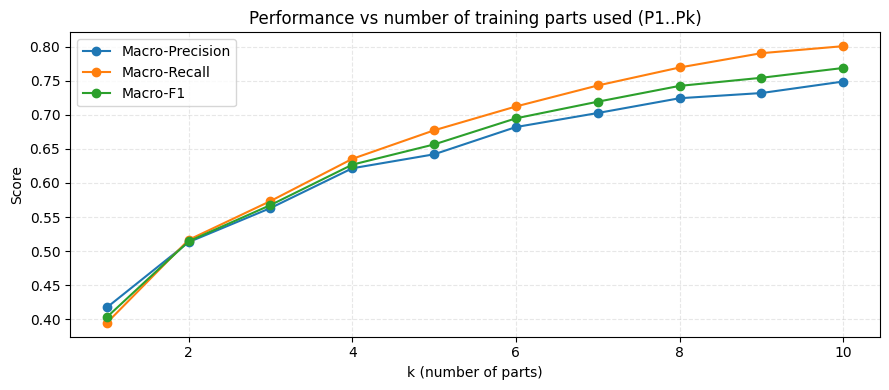


Saved log: C:\Users\franc\Desktop\GitHub\04-Test_2_Data_Scarcity\results\RESNET_data_scarcity_log.txt
Saved plot: C:\Users\franc\Desktop\GitHub\04-Test_2_Data_Scarcity\results\performance_vs_k_parts.png
Saved weights in: C:\Users\franc\Desktop\GitHub\04-Test_2_Data_Scarcity\best_model_resnet


In [7]:
# ===========================
# 6) SAVE PLOT IN RESULTS FOLDER
# ===========================

plot_path = os.path.join(results_dir, "performance_vs_k_parts.png")

plt.figure(figsize=(9, 4))

plt.plot(res_df["k_parts"], res_df["macro_precision"], marker="o", label="Macro-Precision")
plt.plot(res_df["k_parts"], res_df["macro_recall"], marker="o", label="Macro-Recall")
plt.plot(res_df["k_parts"], res_df["macro_f1"], marker="o", label="Macro-F1")

plt.title("Performance vs number of training parts used (P1..Pk)")
plt.xlabel("k (number of parts)")
plt.ylabel("Score")
plt.grid(True, ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(plot_path, dpi=330)
plt.show()

print(f"\nSaved log: {log_path}")
print(f"Saved plot: {plot_path}")
print(f"Saved weights in: {best_resnet_dir}")


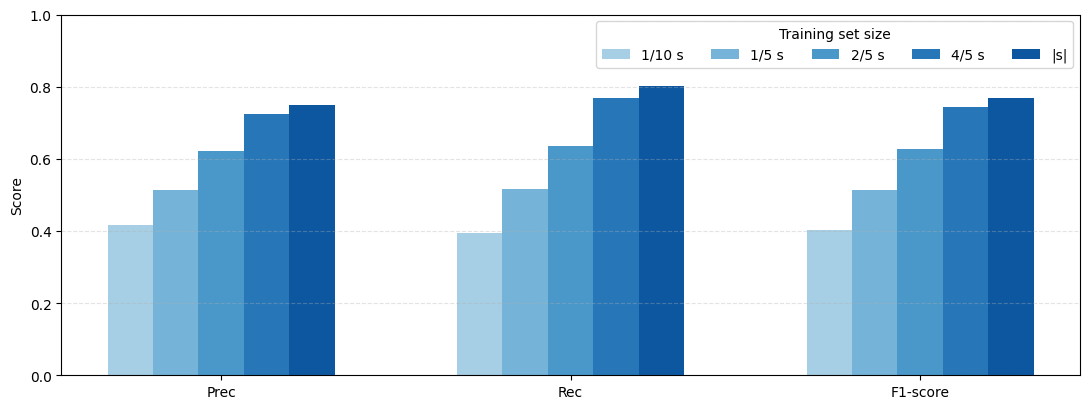

Saved plot: C:\Users\franc\Desktop\GitHub\04-Test_2_Data_Scarcity\results\prf_grouped_training_size.png


In [8]:
# ===========================
# GROUPED BAR PLOT (Prec / Rec / F1) – Bars represent training set size
# ===========================

# Output path
plot_path = os.path.join(results_dir, "prf_grouped_training_size.png")

# Selected training partitions and labels
k_selected = [1, 2, 4, 8, 10]
k_to_label = {
    1: "1/10 s",
    2: "1/5 s",
    4: "2/5 s",
    8: "4/5 s",
    10: "|s|"
}

# Select and sort results by number of parts
res_df_sel = res_df[res_df["k_parts"].isin(k_selected)].copy()
res_df_sel = res_df_sel.sort_values("k_parts")

# Extract metrics
precision = res_df_sel["macro_precision"].values
recall    = res_df_sel["macro_recall"].values
f1_score  = res_df_sel["macro_f1"].values

# Build matrix: rows = training size (k), columns = metrics [Prec, Rec, F1]
values = np.vstack([precision, recall, f1_score]).T

# X-axis groups (metrics)
metrics = ["Prec", "Rec", "F1-score"]
x = np.arange(len(metrics))

# Bar layout parameters
num_bars = len(k_selected)
bar_width = 0.13

# Offsets to center bars within each metric group
offsets = (np.arange(num_bars) - (num_bars - 1) / 2) * bar_width

# Blue color gradients (light → dark)
colors = plt.cm.Blues(np.linspace(0.35, 0.85, num_bars))

plt.figure(figsize=(11, 4.2))

# Plot bars
for i, k in enumerate(k_selected):
    plt.bar(
        x + offsets[i],
        values[i, :],
        width=bar_width,
        color=colors[i],
        label=k_to_label[k]
    )

# Axis formatting
plt.ylim(0, 1.0)
plt.xticks(x, metrics)
plt.ylabel("Score")

# Grid styling
plt.grid(True, axis="y", linestyle="--", alpha=0.35)

# Legend formatting
plt.legend(
    title="Training set size",
    ncol=len(k_selected),
    loc="upper right",
    frameon=True
)

plt.tight_layout()
plt.savefig(plot_path, dpi=330)
plt.show()

print(f"Saved plot: {plot_path}")
